In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def plot_csv_metrics(
    csv_path,
    plot_cols,
    step_col="steps",
    rolling_window=0,
    sort_by_step=True,
    y_max=0.1,          # ← 追加：y軸上限
    y_min=None,         # ← 追加：必要なら下限（例: 0.0）
    clip_y=False,       # ← 追加：上限で値を切る（序盤が潰れすぎるのが嫌なら）
):
    df = pd.read_csv(csv_path)

    df[step_col] = pd.to_numeric(df[step_col], errors="coerce")
    for c in plot_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=[step_col])
    if sort_by_step:
        df = df.sort_values(step_col)

    plt.figure(figsize=(8, 5))
    x = df[step_col].to_numpy()

    for c in plot_cols:
        y = df[c]
        if rolling_window and rolling_window > 1:
            y = y.rolling(rolling_window, min_periods=1).mean()
        if clip_y and (y_max is not None):
            y = y.clip(upper=y_max)
        plt.plot(x, y.to_numpy(), label=c)

    plt.xlabel(step_col)
    plt.ylabel("value")
    plt.legend()
    plt.grid(True)

    # ← ここが本題：y軸範囲を固定
    if y_max is not None:
        plt.ylim(bottom=y_min, top=y_max)
    elif y_min is not None:
        plt.ylim(bottom=y_min)

    plt.show()

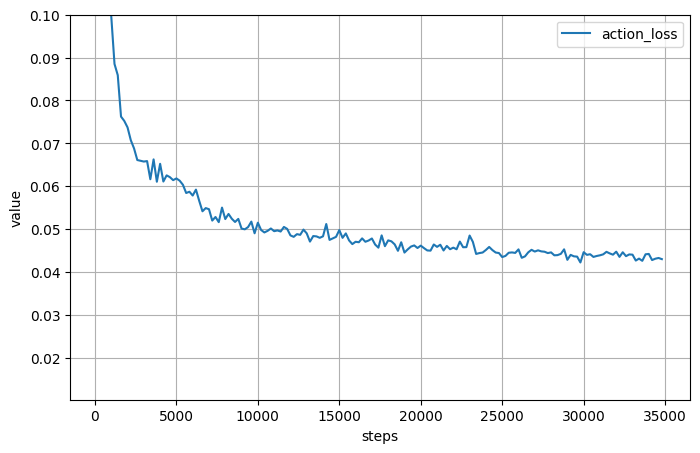

In [3]:
csv_path = "/home/masuoka/lerobot/outputs/pretrain/pretraindata_v1/cotvla/1.0/seed_42/2026-01-10_03-21-21/train_output_log.csv"
plot_csv_metrics(
    csv_path,
    plot_cols=["action_loss"],
    rolling_window=0,
)

In [4]:
def plot_multi_csv_metrics(
    csv_paths,
    plot_cols,
    step_col="steps",
    labels=None,
    sort_by_step=True,
    rolling_window=0,
    dropna=True,
    figsize=(9, 5),
):
    csv_paths = [Path(p) for p in csv_paths]
    for p in csv_paths:
        if not p.exists():
            raise FileNotFoundError(f"CSV not found: {p}")

    if labels is None:
        labels = [p.stem for p in csv_paths]
    if len(labels) != len(csv_paths):
        raise ValueError("labels length must match csv_paths length")

    # カラムごとの線種（必要なら増やしてください）
    linestyles = ["-", "--", ":", "-."]

    plt.figure(figsize=figsize)

    for i, (p, lab) in enumerate(zip(csv_paths, labels)):
        df = pd.read_csv(p)

        if step_col not in df.columns:
            raise ValueError(f'{p}: step_col "{step_col}" not found. cols={list(df.columns)}')
        missing = [c for c in plot_cols if c not in df.columns]
        if missing:
            raise ValueError(f"{p}: missing columns {missing}. cols={list(df.columns)}")

        # 数値変換
        df[step_col] = pd.to_numeric(df[step_col], errors="coerce")
        for c in plot_cols:
            df[c] = pd.to_numeric(df[c], errors="coerce")

        if dropna:
            df = df.dropna(subset=[step_col])

        if sort_by_step:
            df = df.sort_values(step_col)

        x = df[step_col].to_numpy()

        # 1 CSVごとに同じ色が使われる（matplotlibのデフォルトカラーサイクル）
        for j, c in enumerate(plot_cols):
            y = df[c]
            if rolling_window and rolling_window > 1:
                y = y.rolling(rolling_window, min_periods=1).mean()

            ls = linestyles[j % len(linestyles)]
            plt.plot(x, y.to_numpy(), linestyle=ls, label=f"{lab}:{c}")

    plt.xlabel(step_col)
    plt.ylabel("value")
    plt.title(f"{', '.join(plot_cols)} over {step_col}")
    plt.grid(True)
    plt.legend()
    plt.show()

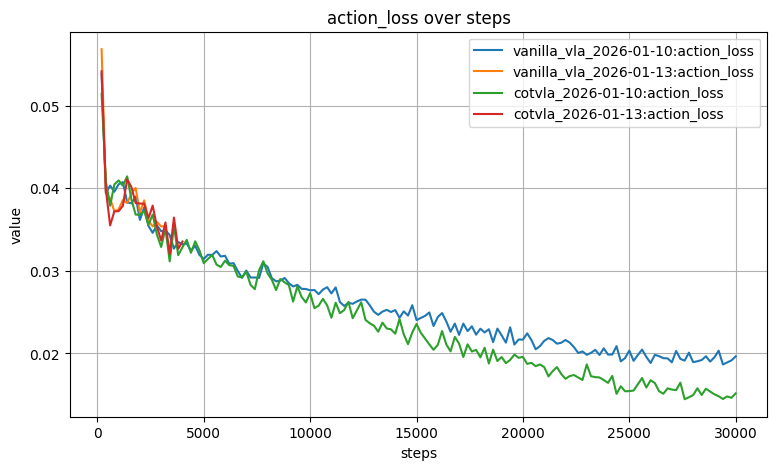

In [ ]:
finetune_csvs = [
    "/home/masuoka/lerobot/outputs/vanilla_vla/task_1/1e-3/seed_42/2026-01-10_17-19-31/train_output_log.csv",
    "/home/masuoka/lerobot/outputs/vanilla_vla/task_1/1e-3/seed_42/2026-01-13_13-20-43/train_output_log.csv",
    "/home/masuoka/lerobot/outputs/cotvla/task_1/0.25/1e-3/seed_42/2026-01-10_18-37-39/train_output_log.csv",
    "/home/masuoka/lerobot/outputs/cotvla/task_1/0.25/1e-3/seed_42/2026-01-13_13-21-02/train_output_log.csv"
]

plot_multi_csv_metrics(
    csv_paths=finetune_csvs,
    plot_cols=["grad_norm"],
    rolling_window=0,
    labels=["vanilla_vla_2026-01-10", "vanilla_vla_2026-01-13", "cotvla_2026-01-10", "cotvla_2026-01-13"]
)

In [14]:
from pathlib import Path
from typing import Iterable, Optional, Union

import pandas as pd
import matplotlib.pyplot as plt

def plot_recon_losses_from_csv(
    csv_path: Union[str, Path],
    *,
    x: str = "steps",
    include: Optional[Iterable[str]] = None,
    title: Optional[str] = None,
    figsize: tuple[float, float] = (9, 5),
    linewidth: float = 2.0,
    alpha: float = 0.95,
    grid: bool = True,
    save_path: Optional[Union[str, Path]] = None,
    show: bool = True,
):
    """
    学習ログCSVから recon_loss と recon_loss/* を比較プロットする。

    Parameters
    ----------
    csv_path : str | Path
        学習ログCSVのパス
    x : str
        x軸に使う列名（例: "steps", "epochs", "samples"）
    include : Iterable[str] | None
        描画する recon_loss 系の列名を明示したい場合に指定。
        None の場合は「recon_loss」と「recon_loss/ で始まる列」を自動検出。
    title : str | None
        図タイトル
    save_path : str | Path | None
        指定すると画像保存する
    show : bool
        Trueで plt.show()

    Returns
    -------
    fig, ax, df
    """
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)

    if x not in df.columns:
        raise ValueError(f"x='{x}' column not found. Available: {list(df.columns)}")

    # --- 対象列の自動検出 ---
    if include is None:
        cols = []
        if "recon_loss" in df.columns:
            cols.append("recon_loss")
        cols += [c for c in df.columns if isinstance(c, str) and c.startswith("recon_loss/")]
        # 重複除去（念のため）
        cols = list(dict.fromkeys(cols))
    else:
        cols = list(include)

    if not cols:
        raise ValueError(
            "No recon_loss columns found. "
            "Expected 'recon_loss' or columns starting with 'recon_loss/'."
        )

    # 数値化（文字列混入があってもNaNに落として描画）
    df[x] = pd.to_numeric(df[x], errors="coerce")
    for c in cols:
        if c not in df.columns:
            raise ValueError(f"Requested column not found: {c}")
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # xでソート（ログがシャッフルされてても綺麗に）
    df = df.sort_values(by=x)

    fig, ax = plt.subplots(figsize=figsize)
    for c in cols:
        ax.plot(df[x], df[c], label=c, linewidth=linewidth, alpha=alpha)

    ax.set_xlabel(x)
    ax.set_ylabel("loss")
    ax.set_title(title or "Reconstruction Loss Comparison")
    ax.legend()
    if grid:
        ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200)

    if show:
        plt.show()

    return fig, ax, df

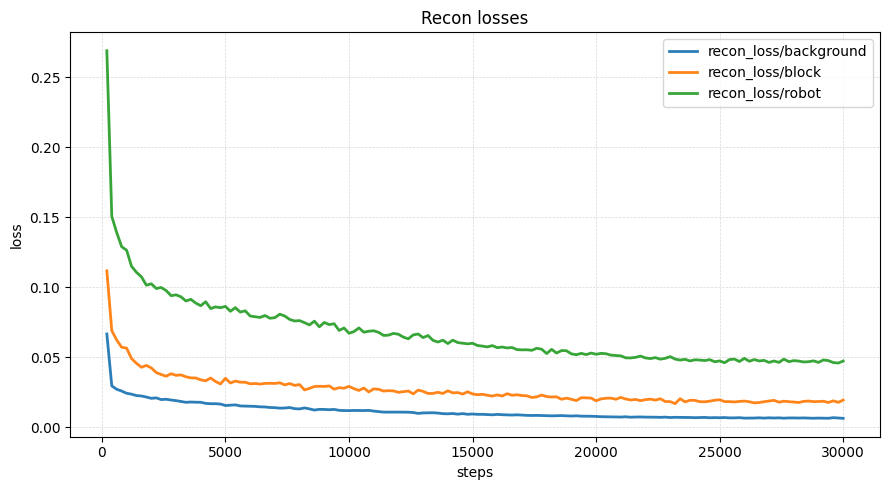

(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Recon losses'}, xlabel='steps', ylabel='loss'>,
        steps     samples      episodes      epochs  action_loss  \
 0      200.0    102400.0    209.086269    2.090863     0.051427   
 1      400.0    204800.0    418.172537    4.181725     0.040829   
 2      600.0    307200.0    627.258806    6.272588     0.037882   
 3      800.0    409600.0    836.345074    8.363451     0.040468   
 4     1000.0    512000.0   1045.431343   10.454313     0.040947   
 ..       ...         ...           ...         ...          ...   
 145  29200.0  14950400.0  30526.595202  305.265952     0.014818   
 146  29400.0  15052800.0  30735.681470  307.356815     0.014487   
 147  29600.0  15155200.0  30944.767739  309.447677     0.014793   
 148  29800.0  15257600.0  31153.854007  311.538540     0.014631   
 149  30000.0  15360000.0  31362.940276  313.629403     0.015163   
 
      dataloading_s  grad_norm  jain_fairness_index        lr  recon_los

In [15]:
plot_path = "/home/masuoka/lerobot/outputs/cotvla/task_1/0.25/1e-3/seed_42/2026-01-10_18-37-39/train_output_log.csv"

plot_recon_losses_from_csv(
    plot_path,
    x="steps",
    include=["recon_loss/background", "recon_loss/block", "recon_loss/robot"],
    title="Recon losses",
)